## 1. Download and extract dataset

In [52]:
import gc
import os.path
import tarfile
from urllib.request import urlretrieve

url = """https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"""
if not os.path.exists(url.split("/")[-1]):
    urlretrieve(url, url.split("/")[-1])
    print("Downloaded.", url)
    with tarfile.open('aclImdb_v1.tar.gz', 'r:gz') as tar:
        tar.extractall()
    print("Extracted.")
else:
    print("Dataset already present.")

Dataset already present.


## 2. a) Load data

In [84]:
import os
import numpy as np

path_train = "aclImdb/train"
path_test = "aclImdb/test"

def load_reviews(base_folder):
    X, y = [], []
    for folder in sorted(os.listdir(base_folder)):
        folder_path = os.path.join(base_folder, folder)
        if not os.path.isdir(folder_path):
            continue

        if folder == "neg":
            label = -1
        elif folder == "pos":
            label = 1
        else:
            continue
        
        files = sorted(os.listdir(folder_path))
        print(f"Reading {folder_path} | label={label} | files={len(files)}")
        for filename in files:
            if filename.endswith(".txt"):
                with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
                    X.append(f.read())
                    y.append(label)
    return X, np.array(y)

# Load data
# Test/Train data sets: 50/50 
X_train, y_train = load_reviews("aclImdb/train")
X_test,  y_test = load_reviews("aclImdb/test")

# Randomize data
# Shuffle within each split to avoid pos/neg ordering effects
rand = np.random.default_rng(0)
idx = rand.permutation(len(X_train))

X_train = [X_train[i] for i in idx]
y_train = y_train[idx]

# for Transformer:
y_train_01 = np.where(y_train == 1, 1, 0)
y_test_01  = np.where(y_test  == 1, 1, 0)

print("Data loaded successfully.")

Reading aclImdb/train/neg | label=-1 | files=12500
Reading aclImdb/train/pos | label=1 | files=12500
Reading aclImdb/test/neg | label=-1 | files=12500
Reading aclImdb/test/pos | label=1 | files=12500
Data loaded successfully.


## 2. b) Sanity check

In [54]:
assert len(X_train) == y_train.shape[0]
assert len(X_test) == y_test.shape[0]
assert len(X_train) == len(X_test)
assert (y_train == 1).sum()  == 12500
assert (y_train == -1).sum() == 12500
assert (y_test  == 1).sum()  == 12500
assert (y_test  == -1).sum() == 12500
assert len(np.unique(y_train))==2
assert len(np.unique(y_test))==2
assert y_train.min() == -1
assert y_train.max() == 1
assert y_test.min() == -1
assert y_test.max() == 1
assert y_train_01.min() == 0
assert y_train_01.max() == 1
assert y_test_01.min() == 0
assert y_test_01.max() == 1

assert all(isinstance(x, str) and len(x) > 0 for x in X_train)
assert all(isinstance(x, str) and len(x) > 0 for x in X_test)

print("Parse implementation complete.")

Parse implementation complete.


## 3. a) SGDClassifier

**Vectorizer**
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

**SGDClassifier**
- Linear classifier trained with stochastic gradient descent (SGD), hinge loss, and L1 regularization.
- Accepts raw text input, **TF-IDF** vectorization is handled internally via fit()
- Follows the sklearn API by inheriting BaseEstimator and ClassifierMixin. BaseEstimator provides get_params() and set_params(). ClassifierMixin provides score() - calls predict() and computes accuracy.
- L1 regularization adds alpha * sign(w) to penalise large weights and push irrelevant feature weights toward zero
- Optimalization adjustments: avoided .toarray() (sparse kept), only "active" samples contribute to the gradient

TF (term frequency): how often a word appears in the document (more appearance = higher score)

IDF (inverse document frequency): how rare a word is across all documents

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.sparse import issparse

class SGDClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self, learning_rate=0.1, alpha=0.001, max_iter=1000, max_features=50_000):
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.max_iter = max_iter
        self.max_features = max_features
        self.coef = None
        self.intercept = None
        self._vectorizer = None

    def _soft_prediction(self, X):
        if issparse(X):
            return X.dot(self.coef) + self.intercept
        return np.dot(X, self.coef) + self.intercept

    # Compute gradient of hinge loss
    def _compute_gradient(self, X, y):
        """
        Args:
            X (array (m, n)): Vectorized document matrix.
            y (array (m,)) : Target labels {-1, 1}.
        Returns:
            grad_coef (array (n,)): grad of loss with resp to weight vector
            grad_intercept (float) : grad of loss 
        """
        n_samples = X.shape[0]
        margin = y * self._soft_prediction(X)

        """
        active[i] = 1 for samples that violate margin >= 1 (need correction)
        active[i] = 0 for samples already correctly classified with confidence
        """
        active = (margin < 1).astype(float)

        # Sum -y[i]*X[i] for all active samples
        if issparse(X):
            grad_coef = -(X.T.dot(active * y)) / n_samples
        else:
            grad_coef = -(np.dot(X.T, active * y)) / n_samples

        grad_intercept = -(active * y).mean()

        # L1 regularization 
        grad_coef += self.alpha * np.sign(self.coef)
        return grad_coef, grad_intercept

    # Update weights using gradient
    def _update_weights(self, grad_coef, grad_intercept):
        self.coef -= self.learning_rate * grad_coef
        self.intercept -= self.learning_rate * grad_intercept

    # Train model
    def fit(self,X,y):
        """
        Args:
            X (list of str) : Raw text documents, length m
            y (array (m,)) : Target labels {-1, 1}, length m
        Returns:
            self: Fitted classifier (allows method chaining)
        """
        self._vectorizer = TfidfVectorizer(max_features=self.max_features)
        X_v = self._vectorizer.fit_transform(X)

        self.coef = np.zeros(X_v.shape[1])
        self.intercept = 0.0

        for _ in range(self.max_iter):
            grad_coef, grad_intercept = self._compute_gradient(X_v, y)
            self._update_weights(grad_coef, grad_intercept)
        return self

    def predict(self, X):
        """
        Args:
            X (list of str) : Raw text documents, length m.
        Returns:
            pred (array (m,)): Predicted labels {-1, 1}.
        """
        X_v  = self._vectorizer.transform(X)
        pred = np.sign(self._soft_prediction(X_v))
        pred[pred == 0] = 1  # resolve ties
        return pred

## 3. b) Logistic Regression
- Vectorization is handled internally via fit().
- Follows the sklearn API by inheriting BaseEstimator and ClassifierMixin.

In [73]:
from sklearn.linear_model import LogisticRegression

class TfidfLogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, max_features=50_000, C=1.0):
        """
        Args:
            max_features (int) : Maximum vocabulary size for TF-IDF vectorizer
            C (float): Inverse regularization strength for LogReg, smaller values = stronger regularization
        """
        self.max_features = max_features
        self.C = C
        self._vectorizer = None
        self._model = None

    def fit(self, X, y):
        """
        Args:
            X (list of str) : Raw text documents, length m
            y (array (m,)) : Target labels, length m
        Returns:
            self: Fitted classifier (allows method chaining)
        """
        self._vectorizer = TfidfVectorizer(max_features=self.max_features)
        X_v = self._vectorizer.fit_transform(X)
        self._model = LogisticRegression(C=self.C, max_iter=1000)
        self._model.fit(X_v, y)
        return self

    def predict(self, X):
        """
        Args:
            X (list of str) : Raw text documents, length m
        Returns:
            pred (array (m,)): Predicted class labels, length m
        """
        X_v = self._vectorizer.transform(X)
        return self._model.predict(X_v)

## 3. c) Training and evaluation
Trains each classifier on the training data, evaluates its accuracy on both training and test sets.

**1. SGDClassifier results:**

*test with increasing iterations (not inluded in solution):*
- *max_iter: 3000*
- *Training accuracy: 0.6997*
- *Test accuracy: 0.7022*

In [74]:
import time
start_time_sgd = time.time()

# Train the model: SGD
model = SGDClassifier()
model.fit(X_train, y_train)

# Evaluate
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

elapsed_sgd = round(time.time() - start_time_sgd,2)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Time: {elapsed_sgd} s")

Training accuracy: 0.6157
Test accuracy: 0.6120
Time: 8.09 s


**2. Logistic Regression results**

In [75]:
start_time_lr = time.time()

# Train the model: LogReg
model = TfidfLogReg()
model.fit(X_train, y_train)

# Evaluate
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

elapsed_lr = round(time.time() - start_time_lr,2)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Time: {elapsed_lr} s")

Training accuracy: 0.9325
Test accuracy: 0.8828
Time: 4.13 s


## 3. d) Final test evaluation


In [77]:
final_model_sgd = SGDClassifier()
final_model_lr = TfidfLogReg()

final_model_sgd.fit(X_train, y_train)
final_model_lr.fit(X_train, y_train)

test_accuracy_sgd = final_model_sgd.score(X_test, y_test)
print("\nFinal test set accuracy, SGD: %.1f%%" % (100*test_accuracy_sgd))

test_accuracy_lr = final_model_lr.score(X_test, y_test)
print("\nFinal test set accuracy, LogReg: %.1f%%" % (100*test_accuracy_lr))


Final test set accuracy, SGD: 61.2%

Final test set accuracy, LogReg: 88.3%


## 3. e) Random baseline, results storage

In [85]:
import time
import random

# Random baseline
start = time.time()
random_acc = sum(random.randint(0, 1) == label for label in y_test_01) / len(y_test_01)
elapsed_random = round(time.time() - start, 2)

baseline_results = {
    'random': {'acc': random_acc,         'time': elapsed_random},
    'sgd':    {'acc': test_accuracy_sgd,  'time': elapsed_sgd},
    'logreg': {'acc': test_accuracy_lr,   'time': elapsed_lr},
}
print(baseline_results)

{'random': {'acc': 0.49648, 'time': 0.02}, 'sgd': {'acc': 0.61196, 'time': 8.09}, 'logreg': {'acc': 0.88284, 'time': 4.13}}


## 4. Transform-based classifier

## 4. a) IMDbDataset

https://huggingface.co/transformers/v3.5.1/custom_datasets.html#seq-imdb

\__len\__, \__getitem\__

In [81]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer

avg_len_01 = int(np.mean([len(text.split()) for text in X_train]))

"""
    Maximum number of tokens each review is cut to before being fed into the transformer.
    Reviews longer than avg_len are truncated, shorter ones are padded with zeros to match the length.
"""
avg_len = int(avg_len_01  / 1.25)
print(f"Using max_len: {avg_len}")

class IMDbDataset(Dataset):
    """
    Map-style PyTorch Dataset for IMDb reviews.
    Tokenizes each review on-the-fly (when requested) in __getitem__.
    Args:
        texts (lst of str) : Raw review strings, length m.
        labels (lst of int) : 0/1 sentiment labels, length m.
        tokenizer : HuggingFace tokenizer instance.
        max_len (int) : Max token length - reviews are truncated/padded.
    """

    def __init__(self, texts, labels, tokenizer, max_len=avg_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        # how many samples are in dataset
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),       # [max_len]
            'attention_mask': enc['attention_mask'].squeeze(0),  # [max_len]
            'label':          torch.tensor(self.labels[idx])     # scalar
        }

batch_size = 32
print("IMDbDataset class ready.")

Using max_len: 186
IMDbDataset class ready.


## 4. b) Sentiment classifier
- used for all models just by passing a different model_name
- **without freezing**: forward pass --> compute loss --> backward pass --> update ALL weights
- **with freezing**: forward pass --> compute loss --> backward pass --> update ONLY classifier head weights
- *why frozen encoder: instead of allocating memory for millions gradient values, PyTorch only allocates gradients for the 1538 parameters in the classifier head*
- *nn.Linear classifier* applied: takes the hidden_size-dimensional CLS (classification) embedding from the transformer (768 for all four models used) and maps it to 2 numbers (one per class). The class with the higher number "wins".

In [62]:
import gc
import torch
import torch.nn as nn
from transformers import AutoModel

class SentimentClassifier(nn.Module):
    """
    Pre-trained transformer encoder (frozen) + trainable classifier head.
    The encoder acts as a feature extractor - only the head is trained.
    Args:
        model_name (str): HuggingFace model identifier.
        num_classes (int): Number of output classes (2 for binary sentiment).
        freeze_encoder(bool): If True, encoder weights are not updated during training.
    """

    def __init__(self, model_name, num_classes=2, freeze_encoder=True):
        # initialize nn.Module's internals
        super().__init__()

        # Load pre-trained transformer
        self._llm = AutoModel.from_pretrained(model_name)

        # Freeze encoder weights: only the classifier head will be trained
        if freeze_encoder:
            for param in self._llm.parameters():
                param.requires_grad = False

        hidden_size = self._llm.config.hidden_size  # 768 for BERT

        # These are the only parameters that get trained in the network since the encoder is frozen
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        # Pass tokens through the transformer encoder
        outputs = self._llm(input_ids=input_ids, attention_mask=attention_mask)

        # [CLS] token at position 0 summarises the whole sequence
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [batch, hidden]

        # Pass CLS embedding through classifier head
        return self.classifier(cls_embedding)  # [batch, num_classes]

    def free_gpu_memory(self):
        """Release memory after training. Call between models."""
        if torch.cuda.is_available():
            print(torch.cuda.memory_summary(device=None, abbreviated=False))
            torch.cuda.empty_cache()
        gc.collect()

## 4. c) Final pipeline

- used: **torch.cuda, AutoTokenizer.from_pretrained, IMDbDataset, DataLoader, SentimentClassifier**

**train_one_epoch**
*total_loss*
- accumulates the sum of loss values across all batches
*correct*
- counts how many predictions were correct
*total*
- counts total samples seen

**Selected models:**
- bert-base-uncased vs. bert-base-multilingual-cased
- roberta-base vs. distilroberta-base


In [63]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Args:
        model: SentimentClassifier instance
        loader: training DataLoader
        optimizer: AdamW optimizer
        criterion: CrossEntropyLoss
        device: torch.device
    Returns:
        avg_loss (float) : mean loss over all batches
        accuracy (float) : fraction of correctly classified samples
    """
    # for each batch: forward pass --> compute loss --> backward --> update weights

    model.train()
    
    #initialises three counters
    total_loss, correct, total = 0.0, 0, 0

    # "unpacks" the dict from __getitem__
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad() # clears the gradients from the previous batch before computing new ones
        logits = model(input_ids, attention_mask) 
        loss = criterion(logits, labels) # compute loss, for each parameter: grad = d(loss) / d(weight)
        loss.backward() # how much each trainable weight contributed to the error, stored in .grad
        optimizer.step() # reads the .grad values and updates the classifier head weights

        preds = logits.argmax(dim=1) # predicted class
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    return total_loss / len(loader), correct / total

# update of grad switched off for evaluate function:
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    return total_loss / len(loader), correct / total

## 4. d) Training

In [64]:
import time
num_epochs = 3

# Device detection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# mono vs. multi | distil vs. full
MODEL_NAMES = [
    ("bert-base-uncased", "mono"),
    ("bert-base-multilingual-cased", "multi"),
    ("distilroberta-base", "distil"),
    ("roberta-base", "full"),
]

all_histories = {}

for model_name, label in MODEL_NAMES:
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    # Each model has its own tokenizer vocabulary — rebuild per model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = IMDbDataset(X_train, y_train_01, tokenizer)
    test_dataset = IMDbDataset(X_test,  y_test_01,  tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    print(f"Device variable: {device}")
    model = SentimentClassifier(model_name).to(device)
    print(f"Model device: {next(model.parameters()).device}")
    
    criterion = nn.CrossEntropyLoss()
    
    # Only pass classifier head parameters, encoder is frozen
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'time': []}

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        print(f"Epoch {epoch}/{num_epochs} started.")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)
        elapsed = round(time.time() - start_time, 2)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['time'].append(elapsed)

        print(f"Epoch {epoch}/{num_epochs} | "
              f"train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.4f} | "
              f"time: {elapsed:.1f}s")

    # Save results for this model
    all_histories[label] = history

    # Free memory before loading next model
    model.free_gpu_memory()
    del model, optimizer, criterion

Using device: mps

Training: bert-base-uncased
Device variable: mps


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model device: mps:0
Epoch 1/3 started.
Epoch 1/3 | train loss: 0.6696  acc: 0.6020 | val loss: 0.6290  acc: 0.7162 | time: 1242.9s
Epoch 2/3 started.
Epoch 2/3 | train loss: 0.6151  acc: 0.7195 | val loss: 0.5798  acc: 0.7574 | time: 1313.3s
Epoch 3/3 started.
Epoch 3/3 | train loss: 0.5772  acc: 0.7521 | val loss: 0.5455  acc: 0.7732 | time: 1277.0s

Training: bert-base-multilingual-cased
Device variable: mps


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model device: mps:0
Epoch 1/3 started.
Epoch 1/3 | train loss: 0.6907  acc: 0.5688 | val loss: 0.6832  acc: 0.7284 | time: 647.2s
Epoch 2/3 started.
Epoch 2/3 | train loss: 0.6774  acc: 0.7142 | val loss: 0.6726  acc: 0.7528 | time: 648.1s
Epoch 3/3 started.
Epoch 3/3 | train loss: 0.6665  acc: 0.7604 | val loss: 0.6624  acc: 0.7877 | time: 652.5s

Training: roberta-base
Device variable: mps


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model device: mps:0
Epoch 1/3 started.
Epoch 1/3 | train loss: 0.6913  acc: 0.5476 | val loss: 0.6884  acc: 0.6454 | time: 1230.5s
Epoch 2/3 started.
Epoch 2/3 | train loss: 0.6863  acc: 0.6236 | val loss: 0.6841  acc: 0.7375 | time: 1230.2s
Epoch 3/3 started.
Epoch 3/3 | train loss: 0.6817  acc: 0.6911 | val loss: 0.6798  acc: 0.7623 | time: 1219.6s


In [65]:
print(all_histories)

{'mono': {'train_loss': [0.6696207979146171, 0.6150600699817433, 0.5772130621592407], 'train_acc': [0.602, 0.71952, 0.75208], 'val_loss': [0.6289853447538507, 0.5798319825507185, 0.5455154583734625], 'val_acc': [0.7162, 0.75736, 0.77324], 'time': [1242.88, 1313.29, 1277.03]}, 'multi': {'train_loss': [0.6954372446707753, 0.6784113237010244, 0.6669030704004381], 'train_acc': [0.50428, 0.57732, 0.61352], 'val_loss': [0.6836526181234424, 0.6681081847004269, 0.6563870307734555], 'val_acc': [0.57028, 0.62004, 0.63632], 'time': [1284.53, 1332.92, 1280.72]}, 'distil': {'train_loss': [0.6906933246366204, 0.6774037067237717, 0.6665362336141679], 'train_acc': [0.56884, 0.71416, 0.7604], 'val_loss': [0.6831673927166882, 0.6726108195684145, 0.6623919236538051], 'val_acc': [0.72836, 0.75276, 0.78772], 'time': [647.17, 648.15, 652.53]}, 'full': {'train_loss': [0.6913169035521309, 0.6862869004306891, 0.681718198158552], 'train_acc': [0.54764, 0.6236, 0.69112], 'val_loss': [0.6883574821759978, 0.684065

## 5. Plot: Loss and Accuracy

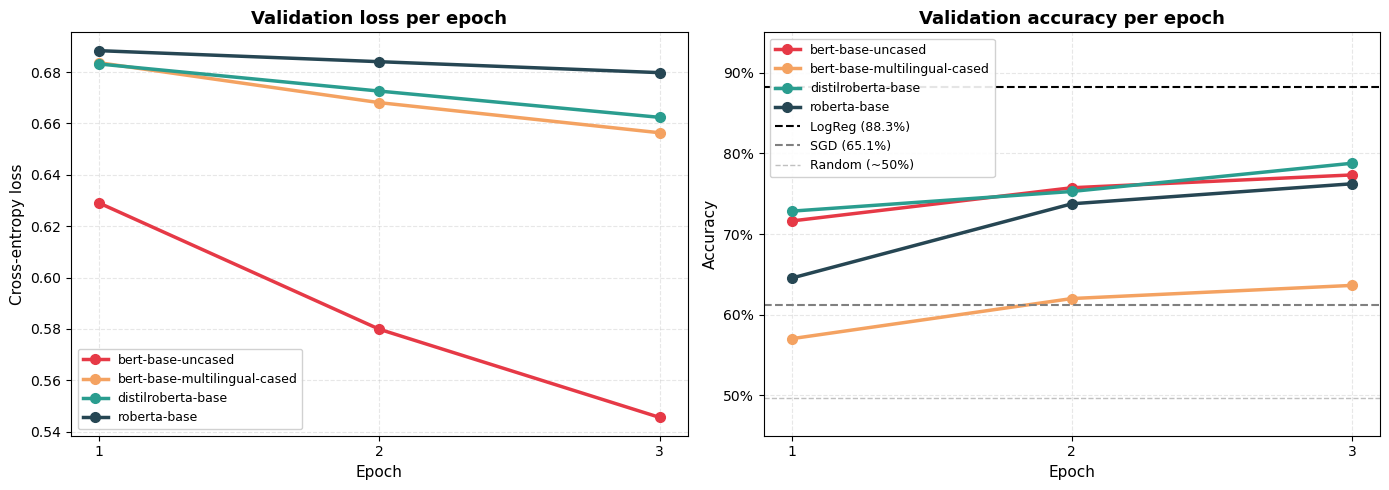

In [89]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = {
    'mono': '#E63946',
    'multi': '#F4A261',
    'distil': '#2A9D8F', 
    'full': '#264653'
}

model_labels = {
    'mono': 'bert-base-uncased',
    'multi': 'bert-base-multilingual-cased',
    'distil': 'distilroberta-base',
    'full': 'roberta-base'
}

epochs = range(1, num_epochs + 1)

# Loss plot
ax = axes[0]
for key, h in all_histories.items():
    ax.plot(epochs, h['val_loss'],
            linestyle='-',
            linewidth=2.5,
            marker='o',
            markersize=7,
            color=colours[key],
            label=model_labels[key])
ax.set_title('Validation loss per epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-entropy loss', fontsize=11)
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

# Accuracy plot
ax = axes[1]
for key, h in all_histories.items():
    ax.plot(epochs, h['val_acc'],
            linestyle='-',
            linewidth=2.5,
            marker='o',
            markersize=7,
            color=colours[key],
            label=model_labels[key])

# baselines
ax.axhline(y=baseline_results['logreg']['acc'], color='black', linestyle='--', linewidth=1.5, label='LogReg (88.3%)')
ax.axhline(y=baseline_results['sgd']['acc'], color='gray', linestyle='--', linewidth=1.5, label='SGD (65.1%)')
ax.axhline(y=baseline_results['random']['acc'], color='silver', linestyle='--', linewidth=1, label='Random (~50%)')

ax.set_title('Validation accuracy per epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xticks(list(range(1, num_epochs + 1)))
ax.set_ylim(0.45, 0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. References:

Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. Advances in Neural Information Processing Systems 32. https://pytorch.org

Wolf, T., et al. (2020). Transformers: State-of-the-Art Natural Language Processing. Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing: System Demonstrations. https://huggingface.co

Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. Proceedings of NAACL-HLT 2019.

Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. arXiv:1910.01108.

Liu, Y., et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. arXiv:1907.11692.

Maas, A., et al. (2011). Learning Word Vectors for Sentiment Analysis. Proceedings of ACL 2011.